# Week 3 Day 2 — Linear Regression

## BinX Tech AI & Machine Learning Internship

This notebook implements a complete linear regression workflow using Scikit-learn.

### Objectives

- Load and inspect a regression dataset.
- Separate the features `X` and target `y`.
- Split the dataset into training and test sets.
- Train a Linear Regression model.
- Generate predictions on unseen test data.
- Interpret the coefficients and intercept.
- Evaluate the model using MAE, RMSE, and R².
- Compare the model against a mean-prediction baseline.
- Determine whether the trained model adds predictive value.

## 1. Importing the Required Libraries

The notebook uses:

- NumPy for numerical calculations.
- Pandas for tabular data manipulation.
- Matplotlib and Seaborn for visualization.
- Scikit-learn for loading data, splitting the dataset, training the model, and calculating evaluation metrics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

The Scikit-learn Diabetes dataset is a regression dataset.

Each row represents one patient. The input features describe different medical measurements, while the target is a continuous measure of disease progression one year after the baseline measurement.

Because the target is numerical and continuous, this is a regression problem.

In [3]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data.copy()

y = diabetes.target.copy()

df = X.copy()
df["target"] = y

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of feature columns: {X.shape[1]}")
print(f"Target column: target")

Dataset loaded successfully.
Number of rows: 442
Number of feature columns: 10
Target column: target


In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000


### Dataset Features

The dataset contains the following ten numerical features:

- `age`: age
- `sex`: sex
- `bmi`: body mass index
- `bp`: average blood pressure
- `s1` to `s6`: six blood-serum measurements

The target represents a quantitative measure of diabetes disease progression.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0000,-0.0000,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0000,0.0000,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0000,-0.0000,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0000,-0.0000,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0000,-0.0000,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0000,0.0000,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0000,-0.0000,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0000,-0.0000,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0000,0.0000,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0000,0.0000,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values in each column:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Total missing values: 0


### Initial Data Inspection

The dataset contains numerical features and a continuous target. No missing values are present, so missing-value treatment is not required before model training.

The features and target have already been separated:

- `X` contains the input features used to make predictions.
- `y` contains the continuous value that the model must predict.

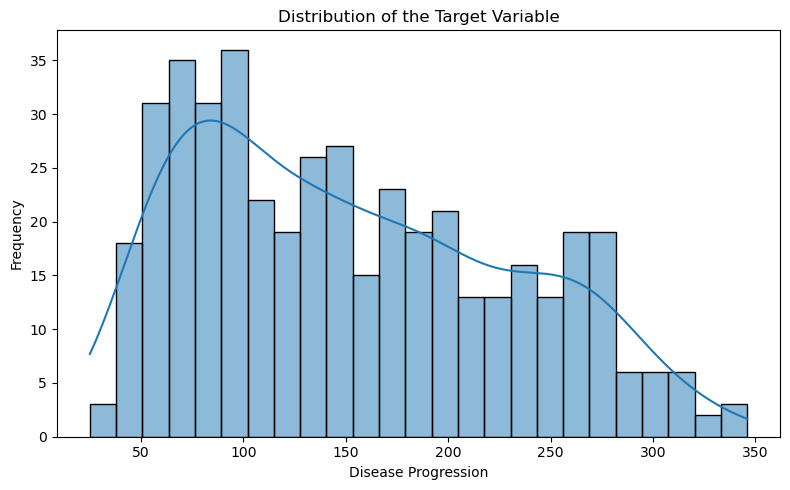

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["target"], bins=25, kde=True)

plt.title("Distribution of the Target Variable")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Target Distribution Interpretation

The histogram shows how the target values are distributed across the patients. The values are continuous, confirming that linear regression is an appropriate starting model.

The target is not a category or class label. Therefore, classification algorithms and classification metrics are not appropriate for this task.

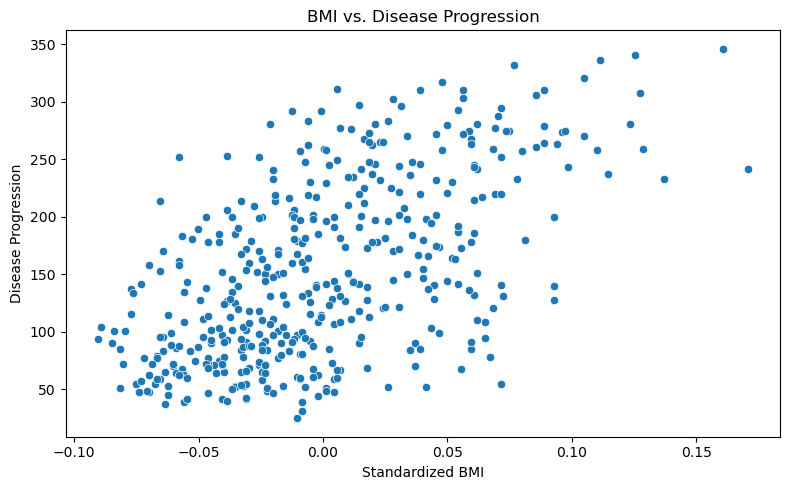

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="bmi", y="target")

plt.title("BMI vs. Disease Progression")
plt.xlabel("Standardized BMI")
plt.ylabel("Disease Progression")
plt.tight_layout()
plt.show()

### BMI Relationship Interpretation

The scatter plot suggests a positive relationship between BMI and the target. In general, higher standardized BMI values appear to be associated with higher disease-progression values.

Linear regression will attempt to represent relationships like this through feature coefficients.

## 3. Separating Features and Target

The model inputs are stored in `X`, while the value being predicted is stored in `y`.

- `X` is a two-dimensional feature matrix.
- `y` is a one-dimensional target series.

In [10]:
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature names:")
print(list(X.columns))

Feature matrix shape: (442, 10)
Target vector shape: (442,)

Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 4. Train/Test Split

The dataset is divided into:

- **80% training data:** used by the model to learn the relationship between the features and target.
- **20% test data:** used only after training to evaluate the model on unseen examples.

A fixed `random_state=42` makes the split reproducible. Running the notebook again will produce the same training and test rows.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training and test sets created successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Training and test sets created successfully.
X_train shape: (353, 10)
X_test shape:  (89, 10)
y_train shape: (353,)
y_test shape:  (89,)


### Why the Test Set Must Remain Unseen

The model must not train on the test set because that would create an unfair evaluation.

If the model sees the test answers during training, it may memorize those examples. Its evaluation results would then appear better than its actual ability to predict new data.

Keeping the test set separate provides a more honest estimate of real-world model performance.

## 5. Training the Linear Regression Model

The Scikit-learn workflow follows these steps:

1. Instantiate the model.
2. Fit the model using the training data.
3. Generate predictions for the test data.
4. Evaluate the predictions.

The model is trained only on `X_train` and `y_train`.

In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 6. Generating Predictions

The trained model now receives the unseen test features and predicts the corresponding target values.

The predictions are stored in `y_pred`.

In [14]:
y_pred = linear_model.predict(X_test)

print(f"Number of predictions: {len(y_pred)}")
print("\nFirst 10 predicted values:")
print(np.round(y_pred[:10], 2))

Number of predictions: 89

First 10 predicted values:
[139.55 179.52 134.04 291.42 123.79  92.17 258.23 181.34  90.22 108.63]


In [15]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})

prediction_results["Absolute_Error"] = np.abs(
    prediction_results["Actual"] - prediction_results["Predicted"]
)

prediction_results.head(10)

,Actual,Predicted,Absolute_Error
0,219.0000,139.5476,79.4524
1,70.0000,179.5172,109.5172
2,202.0000,134.0388,67.9612
3,230.0000,291.4170,61.4170
4,111.0000,123.7897,12.7897
5,84.0000,92.1723,8.1723
6,242.0000,258.2324,16.2324
7,272.0000,181.3373,90.6627
8,94.0000,90.2241,3.7759
9,96.0000,108.6338,12.6338


## 7. Model Coefficients and Intercept

Each feature receives a coefficient.

A positive coefficient means that, while holding the other features constant, an increase in the feature is associated with an increase in the predicted target.

A negative coefficient means that, while holding the other features constant, an increase in the feature is associated with a decrease in the predicted target.

The intercept is the model's predicted starting value when all features are zero.

# Store the coefficients in a readable table
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

# Add absolute coefficient values for ranking
coefficient_table["Absolute_Coefficient"] = coefficient_table[
    "Coefficient"
].abs()

# Sort features from strongest to weakest coefficient magnitude
coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print(f"Model intercept: {linear_model.intercept_:.4f}")

coefficient_table

In [16]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficient_table["Absolute_Coefficient"] = coefficient_table[
    "Coefficient"
].abs()

coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print(f"Model intercept: {linear_model.intercept_:.4f}")

coefficient_table

Model intercept: 151.3456


,Feature,Coefficient,Absolute_Coefficient
0,s1,-931.4888,931.4888
1,s5,736.1989,736.1989
2,bmi,542.4288,542.4288
3,s2,518.0623,518.0623
4,bp,347.7038,347.7038
5,s4,275.3179,275.3179
6,sex,-241.9644,241.9644
7,s3,163.4200,163.4200
8,s6,48.6707,48.6707
9,age,37.9040,37.9040


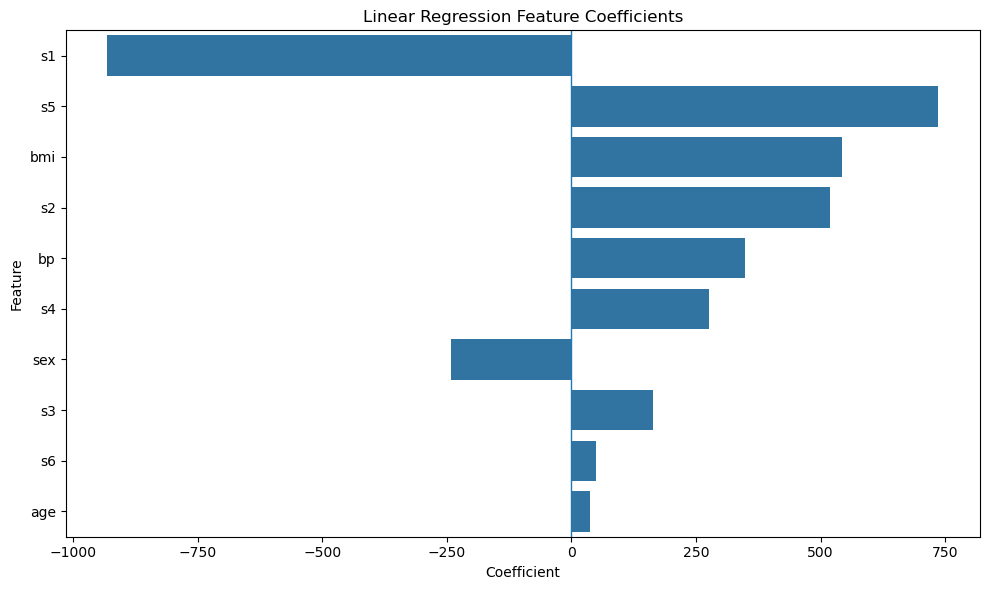

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficient_table,
    x="Coefficient",
    y="Feature"
)

plt.axvline(x=0, linewidth=1)
plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Coefficient Interpretation

The feature with the largest absolute coefficient has the strongest linear effect on the prediction according to this fitted model.

A positive coefficient indicates that increasing the feature is associated with an increase in predicted disease progression, while a negative coefficient indicates an association with a decrease.

Because the Diabetes dataset features are standardized, comparing coefficient magnitudes is more meaningful than it would be if the features used completely different measurement scales.

However, a large coefficient does not prove causation. It only describes the relationship learned by this model while the other features are held constant.

## 8. Model Evaluation

The model is evaluated using three regression metrics.

### Mean Absolute Error — MAE

MAE is the average absolute difference between the actual and predicted values. It is measured in the same units as the target.

Lower MAE is better.

### Root Mean Squared Error — RMSE

RMSE is the square root of the average squared prediction error. Because errors are squared, large errors receive a greater penalty.

Lower RMSE is better.

### Coefficient of Determination — R²

R² measures the proportion of target variation explained by the model.

- `R² = 1`: perfect predictions.
- `R² = 0`: no better than predicting the mean.
- `R² < 0`: worse than a simple mean-prediction baseline.

In [18]:
model_mae = mean_absolute_error(y_test, y_pred)
model_mse = mean_squared_error(y_test, y_pred)
model_rmse = np.sqrt(model_mse)
model_r2 = r2_score(y_test, y_pred)

print("Linear Regression Evaluation")
print("-" * 35)
print(f"MAE:  {model_mae:.4f}")
print(f"RMSE: {model_rmse:.4f}")
print(f"R²:   {model_r2:.4f}")

Linear Regression Evaluation
-----------------------------------
MAE:  42.7941
RMSE: 53.8534
R²:   0.4526


## 9. Mean-Prediction Baseline

A machine-learning model should be compared against a simple baseline.

The baseline used here predicts the mean of the training target for every test example.

This baseline does not learn any relationship between the features and target. Therefore, the Linear Regression model should produce a lower RMSE than this baseline to demonstrate predictive value.

In [19]:
training_target_mean = y_train.mean()

baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=training_target_mean
)

print(f"Training-target mean: {training_target_mean:.4f}")
print(f"Number of baseline predictions: {len(baseline_predictions)}")

Training-target mean: 153.7365
Number of baseline predictions: 89


In [20]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline Evaluation")
print("-" * 35)
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Evaluation
-----------------------------------
MAE:  64.0065
RMSE: 73.2225
R²:   -0.0120


In [21]:
comparison_table = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression"
    ],
    "MAE": [
        baseline_mae,
        model_mae
    ],
    "RMSE": [
        baseline_rmse,
        model_rmse
    ],
    "R2": [
        baseline_r2,
        model_r2
    ]
})

comparison_table

,Model,MAE,RMSE,R2
0,Mean Baseline,64.0065,73.2225,-0.0120
1,Linear Regression,42.7941,53.8534,0.4526


In [22]:
rmse_improvement = baseline_rmse - model_rmse

rmse_improvement_percentage = (
    rmse_improvement / baseline_rmse
) * 100

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Linear Regression RMSE: {model_rmse:.4f}")
print(f"RMSE improvement: {rmse_improvement:.4f}")
print(
    f"RMSE improvement percentage: "
    f"{rmse_improvement_percentage:.2f}%"
)

if model_rmse < baseline_rmse:
    print("\nConclusion: The Linear Regression model beats the baseline.")
    print("The trained model adds predictive value.")
else:
    print("\nConclusion: The model does not beat the baseline.")
    print("The trained model has not demonstrated predictive value.")

Baseline RMSE: 73.2225
Linear Regression RMSE: 53.8534
RMSE improvement: 19.3690
RMSE improvement percentage: 26.45%

Conclusion: The Linear Regression model beats the baseline.
The trained model adds predictive value.


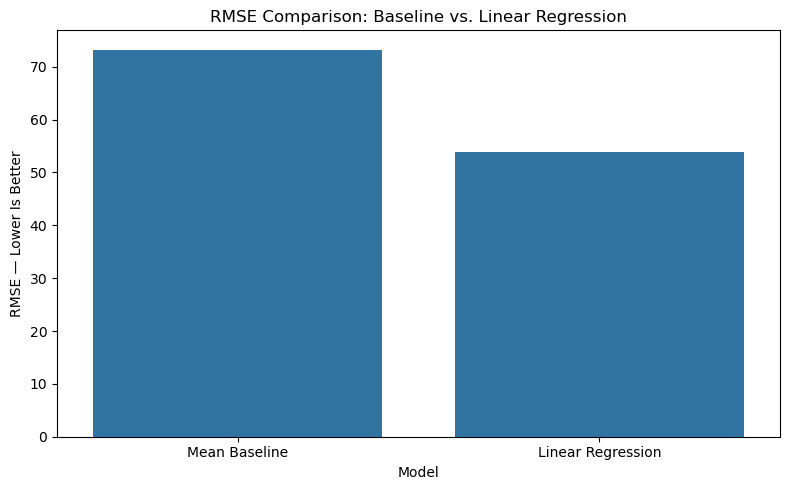

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison: Baseline vs. Linear Regression")
plt.xlabel("Model")
plt.ylabel("RMSE — Lower Is Better")
plt.tight_layout()
plt.show()

### Baseline Comparison

The Linear Regression model produced a lower RMSE than the mean-prediction baseline.

This means the model learned useful relationships between the patient features and the target. It performs better than simply predicting the training-target average for every patient.

Therefore, the model adds predictive value.

The model is not perfect, and its remaining error indicates that the target cannot be fully explained by a simple linear relationship using the available features.

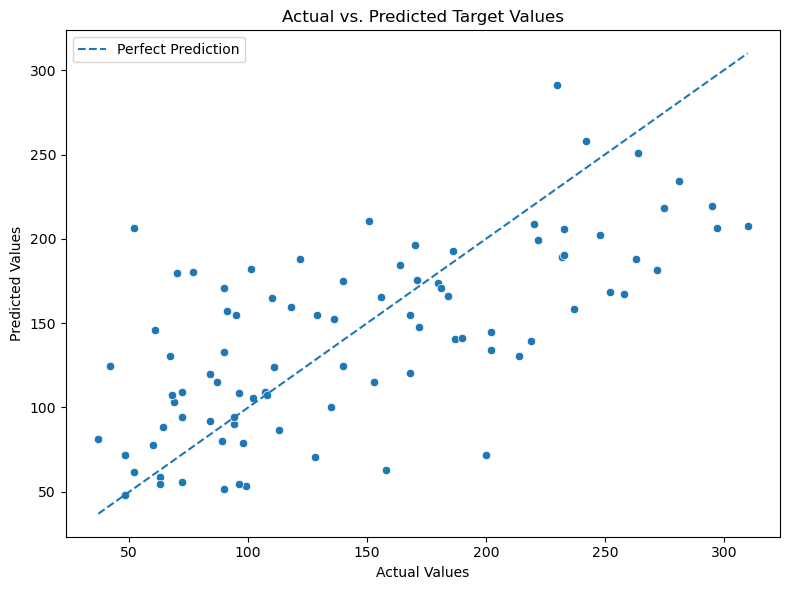

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

# Perfect-prediction reference line
minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs. Predicted Target Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.tight_layout()
plt.show()

### Actual vs. Predicted Interpretation

Each point represents one test observation.

The dashed diagonal line represents perfect predictions, where the predicted value exactly equals the actual value. Points closer to the line represent more accurate predictions, while points farther from the line represent larger prediction errors.

The points generally follow the positive direction of the reference line, showing that the model captures part of the relationship. However, the visible spread around the line confirms that the predictions still contain substantial error.

In [25]:
residuals = y_test.values - y_pred

residual_summary = pd.Series(
    residuals,
    name="Residual"
).describe()

residual_summary

count     89.0000
mean       3.9128
std       54.0154
min     -154.4934
25%      -27.9673
50%        3.7759
75%       43.0409
max      128.3333
Name: Residual, dtype: float64

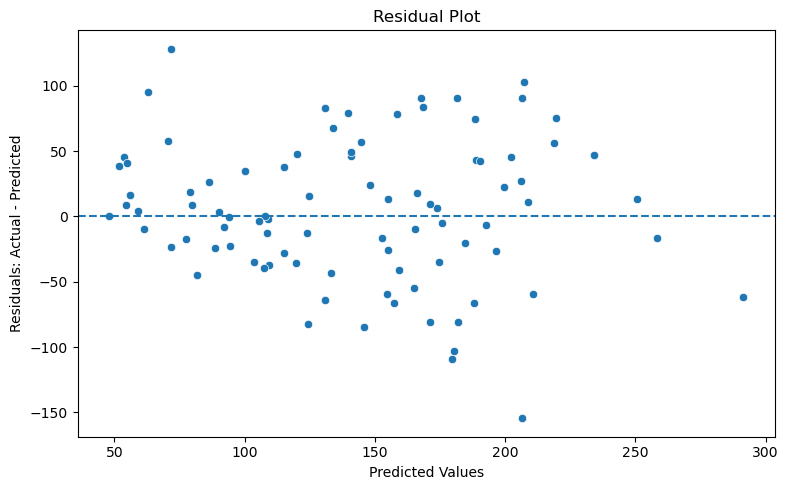

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals: Actual - Predicted")
plt.tight_layout()
plt.show()

### Residual Interpretation

Residuals represent the difference between actual and predicted values.

- A positive residual means the model predicted too low.
- A negative residual means the model predicted too high.
- A residual close to zero indicates an accurate prediction.

For a suitable linear model, residuals should be distributed around zero without a strong systematic pattern. The plot can reveal whether the model consistently overpredicts or underpredicts certain target ranges.

## 10. Final Conclusion

In this notebook, a complete Linear Regression workflow was implemented using Scikit-learn.

The completed steps were:

1. Loaded and inspected the Diabetes regression dataset.
2. Separated the feature matrix `X` and continuous target `y`.
3. Created a reproducible 80/20 train/test split.
4. Trained a Linear Regression model on the training data.
5. Generated predictions for the unseen test data.
6. Extracted and interpreted the model coefficients and intercept.
7. Evaluated the model using MAE, RMSE, and R².
8. Built a baseline that predicts the training-target mean.
9. Compared the Linear Regression model against the baseline.
10. Visualized coefficients, predictions, model comparison, and residuals.

The Linear Regression model achieved a lower RMSE than the baseline, demonstrating that it learned useful predictive relationships from the input features.

However, its R² result also shows that a considerable portion of the target variation remains unexplained. This suggests that the relationship may include nonlinear patterns, interaction effects, unavailable explanatory variables, or noise.

Possible future improvements include:

- Testing nonlinear regression models.
- Applying feature engineering.
- Examining influential observations and outliers.
- Using cross-validation.
- Comparing Linear Regression with Decision Trees and Random Forests.